# Catalog Homes in Ward 3: Mapping Prefabricated Housing in Early 20th Century Washington, D.C.
Jack Witter
Spring 2026

This project uses computational methods to identify, geolocate, and analyze mail-order "kit houses" 
sold by catalog companies such as Sears, Roebuck & Co. and Aladdin Homes within Washington D.C.'s 
Ward 3. By combining building permit records, batch geocoding, historical streetcar data, and modern 
tax assessments, this analysis asks: where did prefabricated housing concentrate in one of D.C.'s 
most affluent wards, and what does its geographic distribution tell us about the relationship between 
transit infrastructure and residential development in the 1920s?*

## Data Sources

DC Building Permit Records (~126,000 rows), filtered to Ward 3 NW addresses 
using a street name lookup derived from the official Ward 3 boundary map.


CleaningL *Official Kits:* Permits where the `Architect` field explicitly names a known catalog company 
(Sears, Roebuck, Honor Bilt, Ready-Cut, Aladdin, Montgomery Ward) & Hidden Kits: Permits where catalog terms appear in unstructured `Builder`, `Permit_Notes`, 
  or `NOTES` fields.

Geocoding: 35,459 unique Ward 3 addresses were submitted in batches to the DC Master Address 
Repository (MAR) batch geocoder, returning precise latitude/longitude coordinates alongside ward, 
ANC, census tract, and parcel SSL identifiers. Match rate: 99.6

Tax assesment merge: Modern property assessment data from DC's Integrated Tax System Public 
Extract was joined to the permit dataset via street address, enabling comparison of current assessed 
values between kit and non-kit properties.

Streetcars: Historical Capital Traction Company line coordinates were manually plotted 
using georeferenced points and converted from DMS to decimal degrees for mapping.

## Methodology

To conduct this analysis, I began by processing and filtering a large dataset of Washington D.C. properties to isolate Ward 3 and identify houses confirmed as historical kit homes. I then performed a data join between these property records and city tax assessment data, using address cleaning and string matching techniques to link the kit houses to their current economic values. To contextualize these findings, I integrated historical geographic data by mapping the path of 1920s-era streetcar lines. Finally, I visualized the results through an interactive map that uses color to represent the era of construction and marker size to reflect modern assessed values, allowing for a direct comparison between the historical development of kit houses and their contemporary financial standing relative to national averages.


## Final Map (See Below):

In [ ]:
#This is an amalgamation of code from the original notebook, with some edits for clarity and presentation for the purpose of presentation The core functionality remains the same: it creates an interactive map of kit houses in Ward 3, DC, with styling based on construction decade and assessed value, and includes streetcar lines and a legend.

import pandas as pd
import numpy as np
import folium

path = '/Users/jwitter24/Desktop/Final Project/ward3_final.csv'
df = pd.read_csv(path, low_memory=False)

kits = df[df['Is_Kit_House'] & df['MAR_LATITUDE'].notna()].copy()
kit_vals = df[df['Is_Kit_House'] & df['NEWTOTAL'].notna()]['NEWTOTAL']

def decade_color(year):
    if year < 1920: return 'blue'
    elif year < 1930: return 'red'
    elif year < 1940: return 'orange'
    else: return 'gray'

def value_to_radius(val):
    """Scale dot size by assessed value — min 5, max 18"""
    if pd.isna(val): return 5
    if val < 500000: return 5
    elif val < 1000000: return 7
    elif val < 1500000: return 9
    elif val < 2000000: return 12
    else: return 18

m = folium.Map(location=[38.93, -77.07], zoom_start=13, tiles='CartoDB positron')

glen_echo_line = [[38.938583, -77.113722], [38.935667, -77.112806], [38.931889, -77.110056], [38.927056, -77.105333], [38.922000, -77.102611], [38.919306, -77.100333], [38.909639, -77.092333], [38.906222, -77.084639], [38.905917, -77.071472], [38.906056, -77.062861]]
wisconsin_line = [[38.906056, -77.062861], [38.915694, -77.067722], [38.922917, -77.073167], [38.928667, -77.073111], [38.934111, -77.072361], [38.948833, -77.080111], [38.951083, -77.080722], [38.960778, -77.085750]]
river_road_line = [[38.948833, -77.080111], [38.949028, -77.080667], [38.956472, -77.091250]]
connecticut_ave_line = [[38.923556, -77.051444], [38.967556, -77.077111]]

folium.PolyLine(glen_echo_line, color='#2196F3', weight=4, opacity=0.7, tooltip='Glen Echo Line').add_to(m)
folium.PolyLine(wisconsin_line, color='#9C27B0', weight=4, opacity=0.7, tooltip='Wisconsin Ave Line').add_to(m)
folium.PolyLine(river_road_line, color='#FF9800', weight=4, opacity=0.7, tooltip='River Road Line').add_to(m)
folium.PolyLine(connecticut_ave_line, color='#E91E63', weight=4, opacity=0.7, tooltip='Connecticut Ave Line').add_to(m)

for _, row in kits.iterrows():
    color = decade_color(row['MapYear'])
    radius = value_to_radius(row['NEWTOTAL'])
    assessed = f"${row['NEWTOTAL']:,.0f}" if pd.notna(row['NEWTOTAL']) else "N/A"
    sale_date = str(row['SALEDATE'])[:4] if pd.notna(row.get('SALEDATE')) else "N/A"
    sale = f"${row['SALEPRICE']:,.0f} ({sale_date})" if pd.notna(row.get('SALEPRICE')) else "N/A"

    folium.CircleMarker(
        location=[row['MAR_LATITUDE'], row['MAR_LONGITUDE']],
        radius=radius,
        popup=(
            f"<b>{row['FULLADDRESS']}</b><br>"
            f"Built: {row['MapYear']}<br>"
            f"Builder: {row['Builder']}<br>"
            f"Assessed Value: {assessed}<br>"
            f"Last Sale: {sale}"
        ),
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.8
    ).add_to(m)

legend_html = """
<div style="position: fixed; bottom: 40px; left: 40px; z-index: 1000;
     background-color: white; padding: 12px; border-radius: 8px;
     border: 1px solid #ccc; font-family: Arial; font-size: 13px;">
  <b>Kit House Era</b><br>
  <span style="color:blue">●</span> Pre-1920s<br>
  <span style="color:red">●</span> 1920s<br>
  <span style="color:orange">●</span> 1930s<br>
  <span style="color:gray">●</span> 1940s+<br><br>
  <b>Dot Size = Assessed Value (2025)</b><br>
  ● &lt; $500k<br>
  ● $500k–$1M<br>
  ● $1M–$1.5M<br>
  ● $1.5M–$2M<br>
  ● &gt; $2M<br><br>
  <b>Streetcar Lines (c. 1920s)</b><br>
  <span style="color:#2196F3">━</span> Glen Echo Line<br>
  <span style="color:#9C27B0">━</span> Wisconsin Ave Line<br>
  <span style="color:#FF9800">━</span> River Road Line<br>
  <span style="color:#E91E63">━</span> Connecticut Ave Line
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))

avg_kit_value = kit_vals.mean()
us_median = 366019 

stats_html = f'''
<div style="
    position: fixed; 
    top: 20px; right: 20px; width: 260px; height: auto; 
    background-color: white; border:2px solid #333; z-index:9999; font-size:14px;
    padding: 12px;
    border-radius: 8px;
    box-shadow: 3px 3px 6px rgba(0,0,0,0.3);
    font-family: 'Arial', sans-serif;
    ">
    <b style="font-size: 15px;">Value Comparison</b><br>
    <hr style="margin: 8px 0; border: 0; border-top: 1px solid #ccc;">
    <table style="width: 100%;">
        <tr>
            <td>Avg US Home:</td>
            <td style="text-align: right;"><b>${us_median:,.0f}</b></td>
        </tr>
        <tr>
            <td>Avg Kit House Lot Price:</td>
            <td style="text-align: right;"><b>${avg_kit_value:,.0f}</b></td>
        </tr>
    </table>
    <div style="font-size: 10px; margin-top: 8px; color: #666; line-height: 1.2;">
        <i>Note: Kit house average reflects assessed values for matched properties in Ward 3 (2025).</i>
    </div>
</div>
'''
m.get_root().html.add_child(folium.Element(stats_html))

#Display the map
m

## The Streetcar Factor
The geographic distribution of kit houses is not random. When plotted against historical Capital Traction Company streetcar routes, kit houses cluster visibly along theWisconsin Avenue and Glen Echo corridors. These are the two lines that opened Tenleytown and the Palisades to commuter development in the early 1920s. This correlation supports the argument that catalog housing was a development technology as much as a consumer product. Builders used kit homes to rapidly populate newly transit-accessible subdivisions at the urban frontier of Northwest Washington.

## Modern Property Values

A Sears catalog home ordered in 1922 cost between $1,000 and $4,000 delivered. The same house today sits at a median assessed value of $1,409,245. This statistically indistinguishable from its conventionally-built neighbors ($1,396,660 median).The mean values diverge sharply ($1.5M kit vs $3.4M non-kit), but this gap is driven 
entirely by a small number of high-value outliers in the non-kit dataset — embassies, commercial parcels, and large apartment buildings that skew the average upward. At the median, any stigma against prefabricated construction has left no measurable trace on Ward 3 property values.

## Further Analysis

There are many other factors that play into how DC's history with kit houses was shaped, one of which could be argued is topography (Seen Below). Towards the top of DC the concentration of kit houses drops, creating that noticable hole in the distribution. Perhaps, due to wealthier residents trying to escape from pollution living a higher points, kit homes were looked down upon in these regions. Not to mentionm, the severity of slopes in this area would make streetcar integration difficult. 

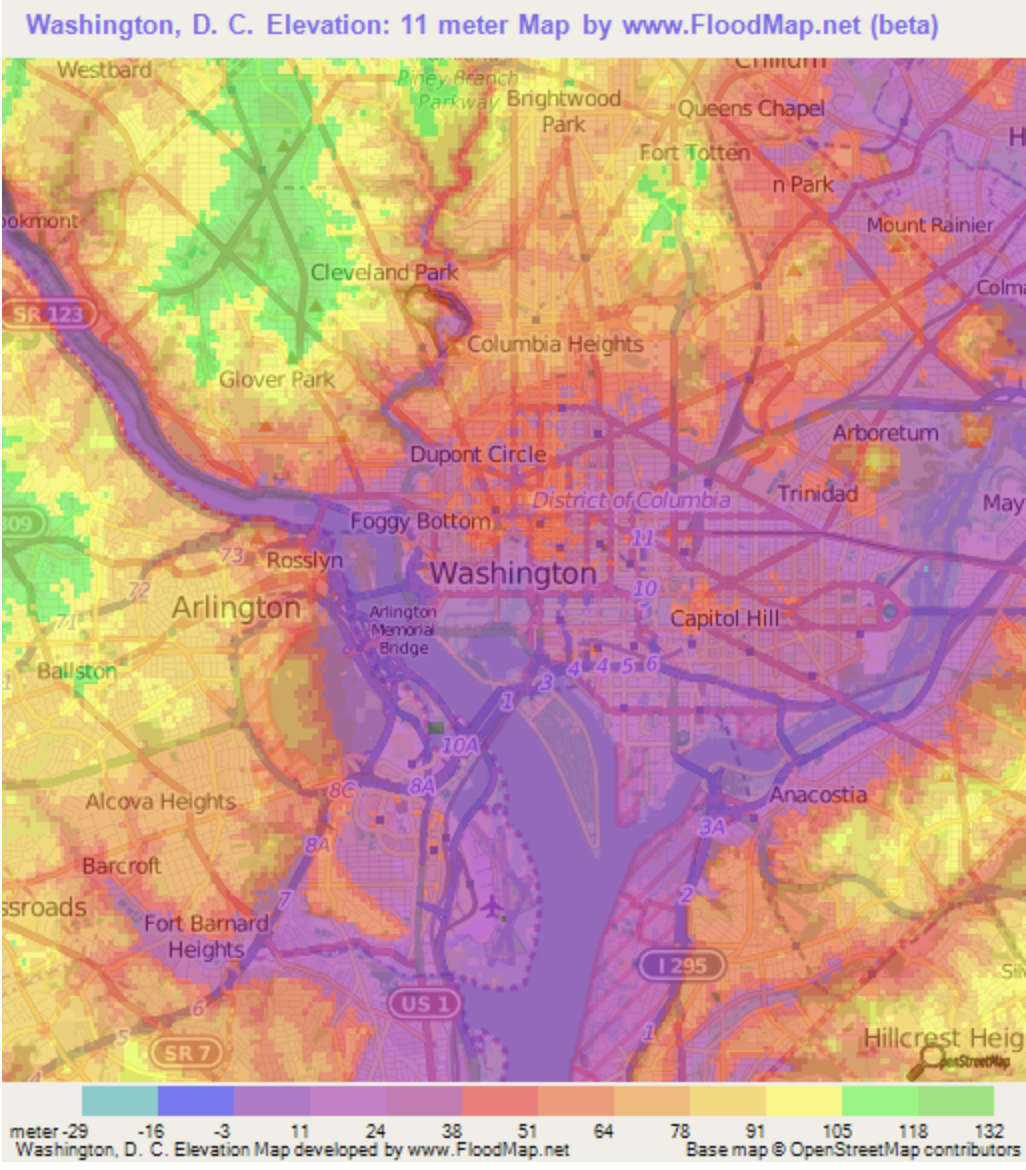

In [ ]:
from IPython.display import Image, display

display(Image(filename='Screenshot 2026-04-29 at 12.42.10 AM.png', width=800))

## Conclusion

In this study, I discovered 119 kit houses across Ward 3, significantly increasing the identified count by using text excavation to find homes that standard queries missed. My analysis showed that these homes were largely built during the 1920s and clustered specifically along historical streetcar corridors, suggesting they were part of a speculative development boom rather than isolated individual builds. Interestingly, I found that these houses now command assessed values nearly identical to their conventionally built neighbors, proving that the historical stigma once associated with "mail-order" homes has completely vanished from the modern market. While I recognize that my findings are limited by gaps in historical permit records and the complexities of address-based data matching, I believe these homes represent an early, transformative era of platform commerce. 